Spam Email Classification 

Convert email text into TF-IDF features and train a Naive Bayes classifier to classify spam vs non-spam emails. Evaluate precision, recall and F1-score. 

Expected Deliverables: Working classifier and evaluation report. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("email.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print(df.info())

print(df.isnull().sum())

print(df['Category'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5573 non-null   str  
 1   Message   5573 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None
Category    0
Message     0
dtype: int64
Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64


In [7]:
df[df["Category"] == '{"mode":"full"']

,Category,Message
5572,"{""mode"":""full""",isActive:false}


In [8]:
df = df[df["Category"].isin(["ham", "spam"])]

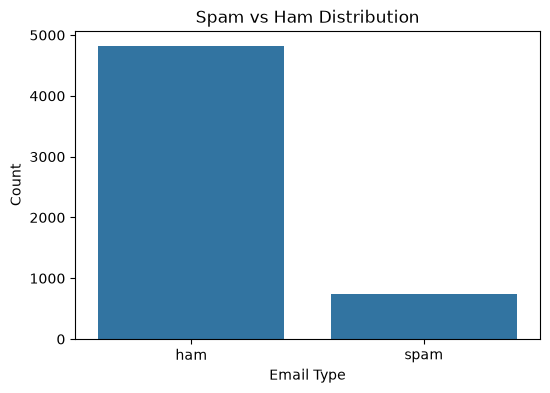

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Category")

plt.title("Spam vs Ham Distribution")
plt.xlabel("Email Type")
plt.ylabel("Count")

plt.show()

In [10]:
df["Category"] = df["Category"].map({
    "ham":0,
    "spam":1
})

In [13]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = tfidf.fit_transform(df["Message"])

y = df["Category"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Naive Bayes Model

In [15]:
model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3859., 598.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[0. ,0. ,0. ,...,0.33,0.43,0.31], [1.9 ,5.64,0.58,...,0.33,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-9.53,-9.53,-9.53,...,-9.25,-9.17,-9.26], [-7.81,-6.98,-8.41,...,-8.59,-8.87,-8.87]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [16]:
y_pred = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9820627802690582
Precision : 1.0
Recall : 0.8657718120805369
F1 Score : 0.9280575539568345


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115

[[966   0]
 [ 20 129]]


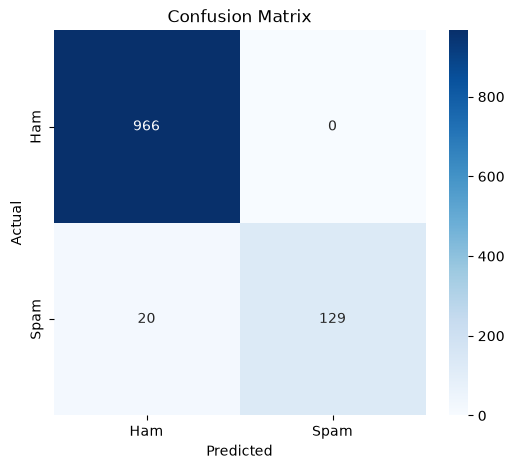

In [17]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

print(cm)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [21]:
email = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize."
]

email_tfidf = tfidf.transform(email)

prediction = model.predict(email_tfidf)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam
